In [3]:
import pandas as pd

In [4]:
customers = pd.read_csv("data/customers.csv")
campaigns = pd.read_csv("data/campaigns.csv")
order_items = pd.read_csv("data/order_items.csv")
orders = pd.read_csv("data/orders.csv")
products = pd.read_csv("data/products.csv")

In [5]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Campaigns:", campaigns.shape)

Orders: (20000, 10)
Order Items: (24073, 6)
Customers: (5000, 9)
Products: (400, 6)
Campaigns: (10, 6)


In [6]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [7]:
monthly_revenue = (
    orders.groupby(pd.Grouper(key="order_date", freq="M"))["order_amount"]
    .sum()
    .reset_index()
    .rename(columns={"order_amount":"monthly_revenue"})
)

C:\Users\hp\AppData\Local\Temp\ipykernel_16212\3940807301.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  orders.groupby(pd.Grouper(key="order_date", freq="M"))["order_amount"]


In [8]:
monthly_revenue

,order_date,monthly_revenue
0,2022-01-31,23867.83
1,2022-02-28,17452.56
2,2022-03-31,19907.67
3,2022-04-30,22568.72
4,2022-05-31,22506.84
5,2022-06-30,22211.47
6,2022-07-31,19265.69
7,2022-08-31,22135.00
8,2022-09-30,19947.57
9,2022-10-31,17908.49


In [9]:
# Create lag features: revenue from previous months
for lag in [1, 2, 3]:
    monthly_revenue[f"lag_{lag}"] = monthly_revenue["monthly_revenue"].shift(lag)

monthly_revenue.head(10)


,order_date,monthly_revenue,lag_1,lag_2,lag_3
0,2022-01-31,23867.83,NaN,NaN,NaN
1,2022-02-28,17452.56,23867.83,NaN,NaN
2,2022-03-31,19907.67,17452.56,23867.83,NaN
3,2022-04-30,22568.72,19907.67,17452.56,23867.83
4,2022-05-31,22506.84,22568.72,19907.67,17452.56
5,2022-06-30,22211.47,22506.84,22568.72,19907.67
6,2022-07-31,19265.69,22211.47,22506.84,22568.72
7,2022-08-31,22135.00,19265.69,22211.47,22506.84
8,2022-09-30,19947.57,22135.00,19265.69,22211.47
9,2022-10-31,17908.49,19947.57,22135.00,19265.69


In [10]:
monthly_revenue["rolling_3"] = (
    monthly_revenue["monthly_revenue"].rolling(window=3).mean()
)
monthly_revenue["rolling_6"] = (
    monthly_revenue["monthly_revenue"].rolling(window=6).mean()
)
monthly_revenue.head(10)

,order_date,monthly_revenue,lag_1,lag_2,lag_3,rolling_3,rolling_6
0,2022-01-31,23867.83,NaN,NaN,NaN,NaN,NaN
1,2022-02-28,17452.56,23867.83,NaN,NaN,NaN,NaN
2,2022-03-31,19907.67,17452.56,23867.83,NaN,20409.353333,NaN
3,2022-04-30,22568.72,19907.67,17452.56,23867.83,19976.316667,NaN
4,2022-05-31,22506.84,22568.72,19907.67,17452.56,21661.076667,NaN
5,2022-06-30,22211.47,22506.84,22568.72,19907.67,22429.010000,21419.181667
6,2022-07-31,19265.69,22211.47,22506.84,22568.72,21328.000000,20652.158333
7,2022-08-31,22135.00,19265.69,22211.47,22506.84,21204.053333,21432.565000
8,2022-09-30,19947.57,22135.00,19265.69,22211.47,20449.420000,21439.215000
9,2022-10-31,17908.49,19947.57,22135.00,19265.69,19997.020000,20662.510000


In [11]:
# Drop rows with NaN caused by lag/rolling
monthly_revenue = monthly_revenue.dropna().reset_index(drop=True)

print(monthly_revenue.shape)
monthly_revenue.head()


(40, 7)


,order_date,monthly_revenue,lag_1,lag_2,lag_3,rolling_3,rolling_6
0,2022-06-30,22211.47,22506.84,22568.72,19907.67,22429.010000,21419.181667
1,2022-07-31,19265.69,22211.47,22506.84,22568.72,21328.000000,20652.158333
2,2022-08-31,22135.00,19265.69,22211.47,22506.84,21204.053333,21432.565000
3,2022-09-30,19947.57,22135.00,19265.69,22211.47,20449.420000,21439.215000
4,2022-10-31,17908.49,19947.57,22135.00,19265.69,19997.020000,20662.510000


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x = monthly_revenue[["lag_1","lag_2","lag_3","rolling_3","rolling_6"]]
y = monthly_revenue["monthly_revenue"]

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, shuffle=False
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (32, 5)
Test shape: (8, 5)


In [15]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [16]:
y_pred = lr.predict(x_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [18]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [19]:
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

MAE: 0.0
RMSE: 0.0
R²: 1.0


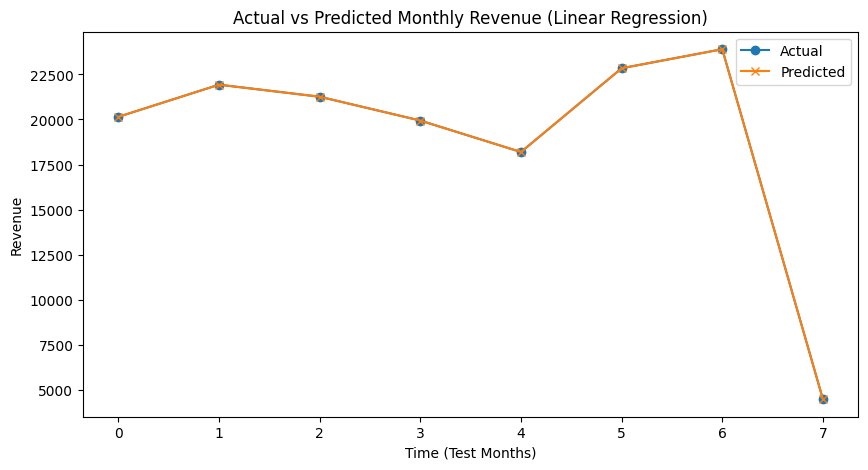

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", marker="o")
plt.plot(y_pred, label="Predicted", marker="x")
plt.title("Actual vs Predicted Monthly Revenue (Linear Regression)")
plt.xlabel("Time (Test Months)")
plt.ylabel("Revenue")
plt.legend()
plt.show()


In [21]:
import numpy as np

In [25]:
def forecast_future(model, data, periods=6):
    forecast = []
    last_row = data.iloc[-1].copy()
    for i in range(periods):
        x_new = pd.DataFrame([[
            last_row["lag_1"],
            last_row["lag_2"],
            last_row["lag_3"],
            last_row["rolling_3"],
            last_row["rolling_6"]
        ]], columns=["lag_1","lag_2","lag_3","rolling_3","rolling_6"])
        y_new = model.predict(x_new)[0]
        forecast.append(y_new)
        last_row["lag_3"] = last_row["lag_2"]
        last_row["lag_2"] = last_row["lag_2"]
        last_row["lag_1"] = y_new
        
        rolling_values = [last_row["rolling_3"], last_row["rolling_6"], y_new]
        last_row["rolling_3"] = np.mean(rolling_values[-3:])
        last_row["rolling_6"] = np.mean(rolling_values[-6:])
    return forecast

future_forecast = forecast_future(lr, monthly_revenue, periods=6)
print("Predicted future revenues:", future_forecast)

Predicted future revenues: [np.float64(4480.859999999985), np.float64(12667.253333333334), np.float64(3818.6388888888805), np.float64(3377.158148148144), np.float64(-2816.2386419753175), np.float64(-7239.490329218108)]
